## Composite 

### Import package

In [ ]:
import os
import sys

import numpy as np
import netCDF4 as nc

from pathlib import Path
from datetime import datetime
from scipy.ndimage import convolve1d
from matplotlib import pyplot as plt
from matplotlib.colors import TwoSlopeNorm
sys.path.append("/home/b11209013/Manuscript_Prep/KW_CRI/src")
import spectrum

### Helper Functions

In [2]:
def convert_time(time_variable: nc.Variable) -> np.ndarray:
    """Return a netCDF time coordinate as YYYY-MM-DD strings."""
    dates = nc.num2date(
        time_variable[:],
        units=time_variable.units,
        calendar=getattr(time_variable, "calendar", "standard"),
    )
    dates_array = np.asarray(dates).ravel()
    return np.asarray(
        [date.strftime("%Y-%m-%d") for date in dates_array],
        dtype=str,
    )

def as_float_array(values: np.ndarray) -> np.ndarray:
    """Convert a netCDF array to float and replace masked values by NaN."""
    masked_values = np.ma.asarray(values, dtype=np.float32)
    return np.asarray(masked_values.filled(np.nan))

### Identifying the KW

#### Load OLR

In [3]:
START_DATE = datetime(2006, 1, 1).strftime("%Y-%m-%d")
END_DATE = datetime(2018, 1, 1).strftime("%Y-%m-%d")
LATITUDE_BOUNDS = (-5.0, 5.0)

with nc.Dataset("/work/DATA/Satellite/OLR/olr_anomaly.nc", "r") as olr_ds:
    olr_dates: np.ndarray = convert_time(olr_ds.variables["time"])
    olr_lat  : np.ndarray = as_float_array(olr_ds.variables["lat"][...])
    olr_lon  : np.ndarray = as_float_array(olr_ds.variables["lon"][...])

    time_mask = (olr_dates >= START_DATE) & (olr_dates <= END_DATE)
    lat_mask  = (olr_lat >= LATITUDE_BOUNDS[0]) & (olr_lat <= LATITUDE_BOUNDS[1])

    olr      : np.ndarray = as_float_array(
        olr_ds.variables["olr"][
            time_mask, lat_mask, :
        ]
    )

olr_nt, olr_ny, olr_nx = olr.shape

#### Preprocessing

In [4]:
# remove time and zonal mean
olr_anom: np.ndarray = olr - np.nanmean(olr, axis=(0, -1), keepdims=True)

# symmetrizing data
olr_symm: np.ndarray = spectrum.symm_asym(olr_anom, lat_axis=1)[0].mean(axis=1)

#### Transform

In [5]:
# set wavenumber and frequency
wnum: np.ndarray = np.fft.fftfreq(olr_nx, d=1/olr_nx)
freq: np.ndarray = np.fft.fftfreq(olr_nt, d=1)

wnums, freqs = np.meshgrid(wnum, freq)

# FFT transform
olr_fft: np.ndarray = np.fft.fft(np.fft.ifft(olr_symm, axis=0), axis=1)

# apply masking
def kelvin_disprel(
        edep: float,
        wnum: np.ndarray
) -> np.ndarray:

    return np.sqrt(9.81 * edep) * 86400.0 / (2*np.pi*6.371e6) * wnum

wnum_lim = ((wnums >= 3) & (wnums <= 8)) | ((wnums <= -3) & (wnums >= -8))
freq_lim = ((freqs >= 1/20) & (freqs <= 1/2.5)) | ((freqs <= -1/20) & (freqs >= -1/2.5))
edep_lim = (freqs >= kelvin_disprel(8, wnums)) & (freqs <= kelvin_disprel(90, wnums)) | \
    (freqs <= kelvin_disprel(8, wnums)) & (freqs >= kelvin_disprel(90, wnums))

mask = wnum_lim & freq_lim & edep_lim

olr_mask = np.where(mask, olr_fft, 0.0)

# IFFT transform
Kelvin_recon: np.ndarray = np.fft.ifft(np.fft.fft(olr_mask, axis=0), axis=1).real


#### Select significant events

In [6]:
# Calculate statistics
mean: float = Kelvin_recon.flatten().mean()
std : float = Kelvin_recon.flatten().std()

criteria: float = mean - 2.96 * std

Kelvin_significant = np.where(Kelvin_recon <= criteria)

time_idx = Kelvin_significant[0]
lon_idx  = Kelvin_significant[1]

lon_val: np.ndarray = np.array([
    olr_lon[l] for l in lon_idx
])

### Composite

#### Load ERA5 Dataset

In [7]:
ERA5_W_PATH = "/data92/b11209013/ERA5_GRIB/Data/ERA5_PRS_W_2006-2017_r1440x721_day.nc"
ERA5_T_PATH = "/data92/b11209013/ERA5_GRIB/Data/ERA5_PRS_T_2006-2017_r1440x721_day.nc"
ERA5_Q_PATH = "/data92/b11209013/ERA5_GRIB/Data/ERA5_PRS_Q_2006-2017_r1440x721_day.nc"
CLOUDSAT_QR_PATH = "/data92/b11209013/CloudSat/DATA/QR_gridded_15layer.nc"

# Load each event day once. The inverse indices map every event back to
# its position along the compact, loaded time axis.
source_event_time_idx = np.asarray(time_idx, dtype=np.intp)
if source_event_time_idx.size == 0:
    raise ValueError("No significant Kelvin-wave events were detected.")
unique_event_time_idx, event_loaded_time_idx = np.unique(
    source_event_time_idx, return_inverse=True
)

with nc.Dataset(ERA5_W_PATH, "r") as ds:
    omega_coords = {
        key: as_float_array(ds.variables[key][...])
        for key in ds.dimensions.keys()
    }

lat_lim = (omega_coords["lat"] >= -5.0) & (omega_coords["lat"] <= 5.0)
lat_indices = np.flatnonzero(lat_lim)
if lat_indices.size == 0:
    raise ValueError("No ERA5 latitudes fall inside the requested bounds.")
lat_slice = slice(lat_indices[0], lat_indices[-1] + 1)

def load_event_latitude_mean(
    path: str,
    variable_name: str,
    selected_times: np.ndarray,
    latitude_slice: slice,
    batch_size: int = 32,
) -> np.ndarray:
    """Load unique event days and average the requested latitude band."""
    with nc.Dataset(path, "r") as ds:
        variable = ds[variable_name]
        if selected_times[-1] >= variable.shape[0]:
            raise ValueError(
                f"Event time index exceeds the {variable_name} time axis."
            )

        result = np.empty(
            (selected_times.size, variable.shape[1], variable.shape[-1]),
            dtype=np.float32,
        )
        for start in range(0, selected_times.size, batch_size):
            stop = min(start + batch_size, selected_times.size)
            block = np.ma.asarray(
                variable[
                    selected_times[start:stop], :, latitude_slice, :
                ],
                dtype=np.float32,
            ).filled(np.nan)
            result[start:stop] = np.nanmean(
                block, axis=2, dtype=np.float32
            )

    return result

omega = load_event_latitude_mean(
    ERA5_W_PATH, "W", unique_event_time_idx, lat_slice
)
T = load_event_latitude_mean(
    ERA5_T_PATH, "T", unique_event_time_idx, lat_slice
)
Q = load_event_latitude_mean(
    ERA5_Q_PATH, "Q", unique_event_time_idx, lat_slice
)
LW = load_event_latitude_mean(
    CLOUDSAT_QR_PATH, "QLW", unique_event_time_idx, lat_slice
)
SW = load_event_latitude_mean(
    CLOUDSAT_QR_PATH, "QSW", unique_event_time_idx, lat_slice
)

ERA5_NT, ERA5_NZ, ERA5_NX = Q.shape
print(
    f"Loaded {ERA5_NT} unique event days for "
    f"{source_event_time_idx.size} event points."
)

/tmp/ipykernel_2077766/367314522.py:54: RuntimeWarning: Mean of empty slice
  result[start:stop] = np.nanmean(


Loaded 596 unique event days for 11069 event points.


#### Preprocessing

In [11]:
# Remove the unique event-day and zonal mean in place. For an all-day
# climatological baseline, load a separately precomputed climatology here.
for field in (omega, T, Q, LW, SW):
    field -= np.nanmean(field, axis=(0, -1), keepdims=True)

omega_anom, T_anom, Q_anom, LW_anom, SW_anom = omega, T, Q, LW, SW

# Pair every event with its position on the compact loaded time axis.
event_time_idx = np.asarray(event_loaded_time_idx, dtype=np.intp)
if event_time_idx.size != lon_val.size:
    raise ValueError("Event time and longitude arrays have different lengths.")

era5_lon = np.asarray(omega_coords["lon"])
lon_spacing = 360.0 / ERA5_NX
if not np.allclose(np.diff(era5_lon), lon_spacing):
    raise ValueError("Expected a regular, increasing ERA5 longitude grid.")
event_lon_idx = (
    np.rint(((lon_val - era5_lon[0]) % 360.0) / lon_spacing).astype(np.intp)
    % ERA5_NX
)
event_shifts = ERA5_NX // 2 - event_lon_idx

def event_centered_composite(
    field: np.ndarray,
    event_times: np.ndarray,
    shifts: np.ndarray,
    batch_size: int = 256,
) -> np.ndarray:
    """Average event snapshots after centering them in longitude."""
    total = np.zeros(field.shape[1:], dtype=np.float64)
    valid_count = np.zeros(field.shape[1:], dtype=np.int64)
    target_lon = np.arange(field.shape[-1])

    for start in range(0, event_times.size, batch_size):
        stop = min(start + batch_size, event_times.size)
        batch = field[event_times[start:stop]]
        source_lon = (
            target_lon[None, :] - shifts[start:stop, None]
        ) % field.shape[-1]
        centered = np.take_along_axis(
            batch, source_lon[:, None, :], axis=-1
        )
        valid = np.isfinite(centered)
        total += np.nansum(centered, axis=0, dtype=np.float64)
        valid_count += valid.sum(axis=0)

    return np.divide(
        total,
        valid_count,
        out=np.full_like(total, np.nan),
        where=valid_count > 0,
    )

omega_composite = event_centered_composite(
    omega_anom, event_time_idx, event_shifts
)
T_composite = event_centered_composite(T_anom, event_time_idx, event_shifts)
Q_composite = event_centered_composite(Q_anom, event_time_idx, event_shifts)

LW_composite = event_centered_composite(LW_anom, event_time_idx, event_shifts)
SW_composite = event_centered_composite(SW_anom, event_time_idx, event_shifts)

print(Q_composite.shape)

(15, 1440)


In [ ]:
# smoothing LW and SW composite structure
LW_composite = np.convolve(LW_composite, np.ones(40)/40, axis=1)

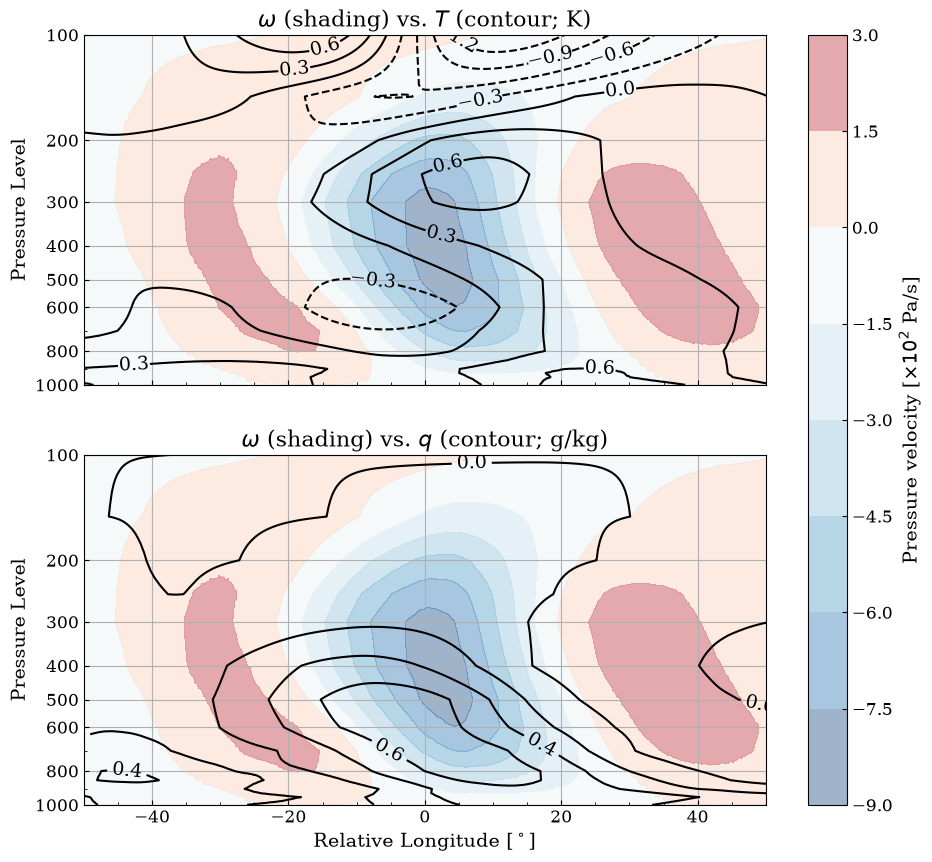

In [12]:
x_rel: np.ndarray = np.linspace(-180, 180, ERA5_NX)
plev : np.ndarray = omega_coords["plev"]/100.0

# general figure configuration
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 14,
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "legend.fontsize": 12,
        "figure.titlesize": 18,
    }
)


fig, axes = plt.subplots(2, 1, figsize=(11, 10), sharex="col")

ax1, ax2 = axes.flatten()

omega_ctf = ax1.contourf(
    x_rel, plev,
    (omega_composite - np.nanmean(omega_composite, axis=1, keepdims=True))*1e2,
    cmap="RdBu_r",
    norm = TwoSlopeNorm(0.0),
    alpha=0.4
    )
T_ct = ax1.contour(
    x_rel, plev,
    T_composite - np.nanmean(T_composite, axis=1, keepdims=True),
    colors="k"
    )
ax1.minorticks_on()
ax1.set_yscale("log")
ax1.set_yticks([100, 200, 300, 400, 500, 600, 800, 1000])
ax1.set_yticklabels(["100", "200", "300", "400", "500", "600", "800", "1000"])
ax1.set_xlim(-50, 50)
ax1.set_ylim(1000, 100)
ax1.set_ylabel("Pressure Level")
ax1.set_title(r"$\omega$ (shading) vs. $T$ (contour; K)")
ax1.grid()
plt.clabel(T_ct, inline=True)

omega_ctf = ax2.contourf(
    x_rel, plev,
    (omega_composite - np.nanmean(omega_composite, axis=1, keepdims=True))*1e2,
    cmap="RdBu_r",
    norm = TwoSlopeNorm(0.0),
    alpha=0.4
    )

Q_ct = ax2.contour(
    x_rel, plev,
    (Q_composite - np.nanmean(Q_composite, axis=1, keepdims=True))*1e3,
    colors="k"
    )
ax2.minorticks_on()
ax2.set_yscale("log")
ax2.set_yticks([100, 200, 300, 400, 500, 600, 800, 1000])
ax2.set_yticklabels(["100", "200", "300", "400", "500", "600", "800", "1000"])
ax2.set_xlim(-50, 50)
ax2.set_xlabel(r"Relative Longitude [$^\circ$]")
ax2.set_ylim(1000, 100)
ax2.set_ylabel("Pressure Level")
ax2.set_title(r"$\omega$ (shading) vs. $q$ (contour; g/kg)")
ax2.grid()
fig.colorbar(omega_ctf, ax=axes, label=r"Pressure velocity [$\times 10^2$ Pa/s]")
plt.clabel(Q_ct, inline=True)

plt.savefig("/home/b11209013/Manuscript_Prep/KW_CRI/Figure/wTQ_composite.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


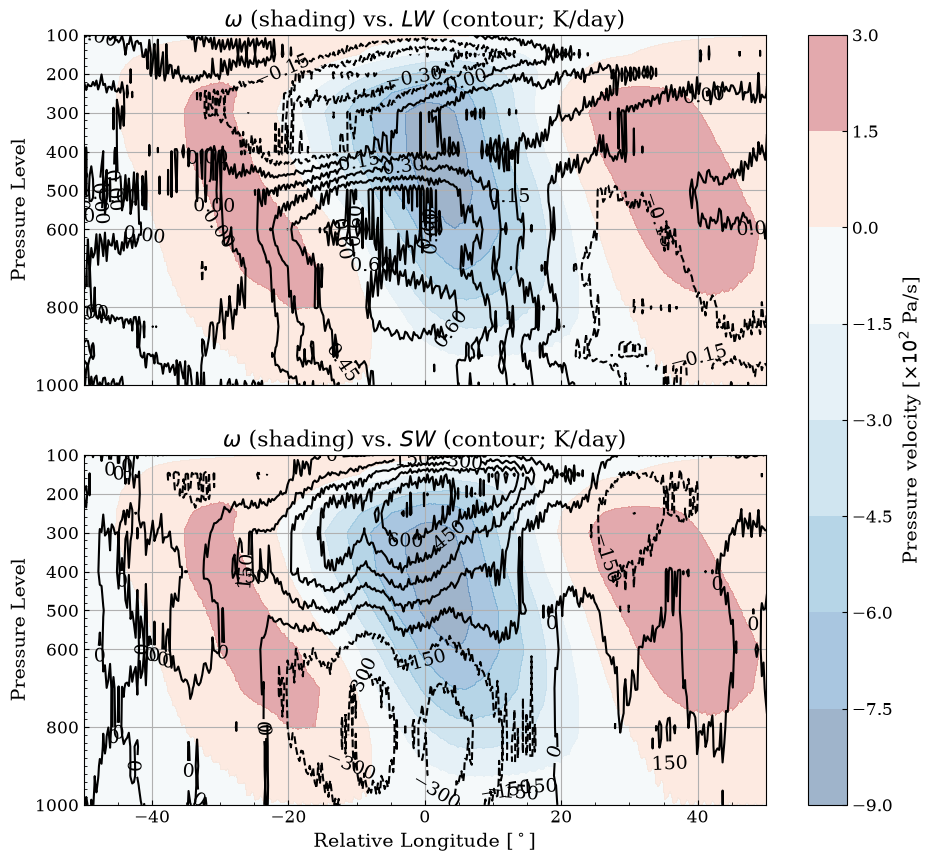

In [ ]:

fig, axes = plt.subplots(2, 1, figsize=(11, 10), sharex="col")

ax1, ax2 = axes.flatten()

omega_ctf = ax1.contourf(
    x_rel, plev,
    (omega_composite - np.nanmean(omega_composite, axis=1, keepdims=True))*1e2,
    cmap="RdBu_r",
    norm = TwoSlopeNorm(0.0),
    alpha=0.4
    )
LW_ct = ax1.contour(
    x_rel, plev,
    LW_composite - np.nanmean(LW_composite, axis=1, keepdims=True),
    colors="k"
    )
ax1.minorticks_on()
ax1.set_yticks([100, 200, 300, 400, 500, 600, 800, 1000])
ax1.set_yticklabels(["100", "200", "300", "400", "500", "600", "800", "1000"])
ax1.set_xlim(-50, 50)
ax1.set_ylim(1000, 100)
ax1.set_ylabel("Pressure Level")
ax1.set_title(r"$\omega$ (shading) vs. $LW$ (contour; K/day)")
ax1.grid()
plt.clabel(LW_ct, inline=True)

omega_ctf = ax2.contourf(
    x_rel, plev,
    (omega_composite - np.nanmean(omega_composite, axis=1, keepdims=True))*1e2,
    cmap="RdBu_r",
    norm = TwoSlopeNorm(0.0),
    alpha=0.4
    )

SW_ct = ax2.contour(
    x_rel, plev,
    (SW_composite - np.nanmean(SW_composite, axis=1, keepdims=True))*1e3,
    colors="k"
    )
ax2.minorticks_on()
ax2.set_yticks([100, 200, 300, 400, 500, 600, 800, 1000])
ax2.set_yticklabels(["100", "200", "300", "400", "500", "600", "800", "1000"])
ax2.set_xlim(-50, 50)
ax2.set_xlabel(r"Relative Longitude [$^\circ$]")
ax2.set_ylim(1000, 100)
ax2.set_ylabel("Pressure Level")
ax2.set_title(r"$\omega$ (shading) vs. $SW$ (contour; K/day)")
ax2.grid()
fig.colorbar(omega_ctf, ax=axes, label=r"Pressure velocity [$\times 10^2$ Pa/s]")
plt.clabel(SW_ct, inline=True)

plt.savefig("/home/b11209013/Manuscript_Prep/KW_CRI/Figure/LWSW_composite.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)
